# Benchmark Analysis — io_uring vs prim_file

Statistical comparison of throughput and P99 latency between RabbitMQ's
default write path (`prim_file`/`file:write`) and the `io_uring`
integration built in this project.

**Run with:** `bench_statistical.sh` or `bench_consumer.sh`  
**Parameters:** read from `BENCH_*` environment variables

In [1]:
import os, csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# ── parameters ────────────────────────────────────────────────────────────
BASELINE_CSV  = os.environ.get('BENCH_BASELINE_CSV',  'bench-results/baseline.csv')
IOURING_CSV   = os.environ.get('BENCH_IOURING_CSV',   'bench-results/iouring.csv')
RUNS          = int(os.environ.get('BENCH_RUNS',       '30'))
DURATION      = int(os.environ.get('BENCH_DURATION',   '10'))
PRODUCERS     = int(os.environ.get('BENCH_PRODUCERS',  '4'))
CONSUMERS     = int(os.environ.get('BENCH_CONSUMERS',  '0'))
MSG_SIZE      = int(os.environ.get('BENCH_SIZE',       '1024'))
CONSUMER_MODE = os.environ.get('BENCH_CONSUMER_MODE', '0') == '1'
OUT_DIR       = Path(BASELINE_CSV).parent

print(f'Baseline CSV : {BASELINE_CSV}')
print(f'io_uring CSV : {IOURING_CSV}')
print(f'Mode         : {"consumer" if CONSUMER_MODE else "write"}')
print(f'Runs / dur.  : {RUNS} × {DURATION}s')
print(f'Msg size     : {MSG_SIZE} B')

Baseline CSV : baseline.csv
io_uring CSV : iouring.csv
Mode         : write
Runs / dur.  : 30 × 10s
Msg size     : 1024 B


## 1. Loading the data

In [2]:
def load_csv(path: str) -> tuple[np.ndarray, np.ndarray | None]:
    tp, p99 = [], []
    with open(path) as f:
        for row in csv.reader(f):
            if not row:
                continue
            try:
                tp.append(float(row[0]))
                if len(row) >= 2:
                    p99.append(float(row[1]))
            except ValueError:
                pass
    return np.array(tp), (np.array(p99) if p99 else None)

b_tp, b_p99 = load_csv(BASELINE_CSV)
i_tp, i_p99 = load_csv(IOURING_CSV)

if CONSUMER_MODE:
    b_p99 = i_p99 = None

assert len(b_tp) == len(i_tp), \
    f'baseline has {len(b_tp)} runs but io_uring has {len(i_tp)} - the paired t-test needs 1:1 rounds'
if b_p99 is not None:
    assert len(b_p99) == len(i_p99), \
        f'baseline has {len(b_p99)} p99 samples but io_uring has {len(i_p99)} - the paired t-test needs 1:1 rounds'

print(f'Baseline  : {len(b_tp)} runs  |  mean {b_tp.mean():,.0f} msg/s')
print(f'io_uring  : {len(i_tp)} runs  |  mean {i_tp.mean():,.0f} msg/s')
if b_p99 is not None:
    print(f'P99 baseline  : {b_p99.mean():,.0f} µs')
    print(f'P99 io_uring  : {i_p99.mean():,.0f} µs')

Baseline  : 30 runs  |  mean 42,248 msg/s
io_uring  : 30 runs  |  mean 50,416 msg/s
P99 baseline  : 28,138 µs
P99 io_uring  : 23,942 µs


## 2. Statistical Analysis

For each metric (throughput, p99 latency) we run two pairs of tests:

- **Paired (primary)**: the design is interleaved — round *i* of
  `baseline.csv` and round *i* of `iouring.csv` come from the same
  iteration of `run_pair()` in `bench_statistical.sh` (both brokers run
  at the same time, no restart between rounds, baseline then io_uring
  back to back). We use the **paired t-test** plus **Wilcoxon
  signed-rank** as a non-parametric fallback, with **Cohen's dz**
  (mean of the differences / std of the differences) as the effect size.
- **Independent (secondary, sanity check)**: **Welch's t-test** plus
  **Mann-Whitney U** as a non-parametric fallback, with **Cohen's d**
  (pooled standard deviation) as the effect size.

Before trusting the paired t-test we run **Shapiro-Wilk** on the
per-round differences (`io_uring - baseline`) and plot a Q-Q plot. If
the differences are not normal, the Wilcoxon result is the one to trust.

We also report a **95% bootstrap CI** (10,000 samples) for each group
mean and for the mean difference Δ.

Sign convention: d/dz = (io_uring - baseline) / spread. A positive value
means io_uring's raw number is higher. For throughput, higher is better,
so positive = good. For p99 latency, lower is better, so negative = good.

Two outcomes are tested here (throughput and p99 latency), so we use a
Bonferroni-corrected alpha = 0.05 / 2 = 0.025.

In [3]:
def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    pooled = np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2)
    return (a.mean() - b.mean()) / pooled if pooled else 0.0

def cohens_d_paired(diff: np.ndarray) -> float:
    sd = diff.std(ddof=1)
    return diff.mean() / sd if sd else 0.0

def ci95(data: np.ndarray) -> tuple[float, float]:
    rng = np.random.default_rng(42)
    boot = [rng.choice(data, size=len(data), replace=True).mean() for _ in range(10_000)]
    return float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))

def effect_label(d: float) -> str:
    d = abs(d)
    if d < 0.2: return 'negligible'
    if d < 0.5: return 'small'
    if d < 0.8: return 'medium'
    return 'large'

def sig_stars(p: float) -> str:
    if p < 0.001: return '*** (p < 0.001)'
    if p < 0.01:  return '**  (p < 0.01)'
    if p < 0.05:  return '*   (p < 0.05)'
    return 'ns  (p ≥ 0.05)'

def normality_label(p: float) -> str:
    return 'normal' if p >= 0.05 else 'not normal -> trust Wilcoxon instead'

def bonferroni_verdict(p: float, alpha: float) -> str:
    return 'significant' if p < alpha else 'NOT significant'

ALPHA      = 0.05
ALPHA_BONF = ALPHA / 2  # 2 outcomes tested (throughput, p99 latency)
has_p99    = b_p99 is not None and len(b_p99) > 0

# Throughput
diff_tp        = i_tp - b_tp
t_tp, p_tp     = stats.ttest_ind(i_tp, b_tp, equal_var=False)
u_tp, p_u_tp   = stats.mannwhitneyu(i_tp, b_tp, alternative='two-sided')
t_tp_p, p_tp_p = stats.ttest_rel(i_tp, b_tp)
w_tp, p_w_tp   = stats.wilcoxon(diff_tp)
sw_tp, p_sw_tp = stats.shapiro(diff_tp)
d_tp           = cohens_d(i_tp, b_tp)
dz_tp          = cohens_d_paired(diff_tp)
ci_b_tp        = ci95(b_tp)
ci_i_tp        = ci95(i_tp)
ci_diff_tp     = ci95(diff_tp)
delta_tp       = i_tp.mean() - b_tp.mean()
delta_tp_p     = (i_tp.mean() / b_tp.mean() - 1) * 100

tp_label  = 'Consumer Throughput' if CONSUMER_MODE else 'Throughput'
hdr_label = (f'{CONSUMERS} consumers' if CONSUMER_MODE else f'{PRODUCERS} producers')

sep = '═' * 62
print(f'\n{sep}')
print(f'  STATISTICAL ANALYSIS — {RUNS} runs × {DURATION}s')
print(f'  {hdr_label} | {MSG_SIZE} B | persistent | io_uring vs prim_file')
print(f'  Bonferroni-adjusted alpha (2 outcomes) = {ALPHA_BONF}')
print(sep)
print(f'\n  ┌── {tp_label.upper()} (msg/s) ──────────────────────────────────┐')
print(f'  {"Baseline (prim_file)":<24} {b_tp.mean():>12,.1f}   CI₉₅=[{ci_b_tp[0]:,.0f}, {ci_b_tp[1]:,.0f}]')
print(f'  {"io_uring":<24} {i_tp.mean():>12,.1f}   CI₉₅=[{ci_i_tp[0]:,.0f}, {ci_i_tp[1]:,.0f}]')
print(f'  {"mean Δ":<24} {delta_tp:>+12,.1f}   ({delta_tp_p:+.1f}%)')
print(f'  Δ CI₉₅ (bootstrap)      [{ci_diff_tp[0]:>+,.0f}, {ci_diff_tp[1]:>+,.0f}]')
print(f'  Welch          t({len(b_tp)+len(i_tp)-2:.0f}) = {t_tp:.3f},  p = {p_tp:.4e}  {sig_stars(p_tp)}')
print(f'  Mann-Whitney U = {u_tp:.1f},  p = {p_u_tp:.4e}  {sig_stars(p_u_tp)}')
print(f'  Paired t({len(b_tp)-1:.0f})       = {t_tp_p:.3f},  p = {p_tp_p:.4e}  {sig_stars(p_tp_p)}  ← interleaved')
print(f'  Wilcoxon signed-rank = {w_tp:.1f},  p = {p_w_tp:.4e}  {sig_stars(p_w_tp)}')
print(f'  Shapiro-Wilk (diff)  W = {sw_tp:.3f},  p = {p_sw_tp:.4e}  -> {normality_label(p_sw_tp)}')
print(f"  Cohen's d  (independent) = {d_tp:.3f}  ({effect_label(d_tp)})")
print(f"  Cohen's dz (paired)      = {dz_tp:.3f}  ({effect_label(dz_tp)})")

stats_res = dict(t_tp=t_tp, p_tp=p_tp, d_tp=d_tp, dz_tp=dz_tp,
                  t_p99=None, p_p99=None, d_p99=None, dz_p99=None)

if has_p99:
    diff_p99         = i_p99 - b_p99
    t_p99, p_p99     = stats.ttest_ind(i_p99, b_p99, equal_var=False)
    u_p99, p_u_p99   = stats.mannwhitneyu(i_p99, b_p99, alternative='two-sided')
    t_p99_p, p_p99_p = stats.ttest_rel(i_p99, b_p99)
    w_p99, p_w_p99   = stats.wilcoxon(diff_p99)
    sw_p99, p_sw_p99 = stats.shapiro(diff_p99)
    d_p99            = cohens_d(i_p99, b_p99)
    dz_p99           = cohens_d_paired(diff_p99)
    ci_b_p99         = ci95(b_p99)
    ci_i_p99         = ci95(i_p99)
    ci_diff_p99      = ci95(diff_p99)
    delta_p99        = i_p99.mean() - b_p99.mean()
    delta_p99_p      = (i_p99.mean() / b_p99.mean() - 1) * 100
    stats_res.update(dict(t_p99=t_p99, p_p99=p_p99, d_p99=d_p99, dz_p99=dz_p99))

    print(f'\n  ┌── CONFIRM P99 LATENCY (µs) ─────────────────────────────────┐')
    print(f'  {"Baseline (prim_file)":<24} {b_p99.mean():>12,.1f} µs  CI₉₅=[{ci_b_p99[0]:,.0f}, {ci_b_p99[1]:,.0f}]')
    print(f'  {"io_uring":<24} {i_p99.mean():>12,.1f} µs  CI₉₅=[{ci_i_p99[0]:,.0f}, {ci_i_p99[1]:,.0f}]')
    print(f'  {"mean Δ":<24} {delta_p99:>+12,.1f}   ({delta_p99_p:+.1f}%)')
    print(f'  Δ CI₉₅ (bootstrap)      [{ci_diff_p99[0]:>+,.0f}, {ci_diff_p99[1]:>+,.0f}]')
    print(f'  Welch          t({len(b_p99)+len(i_p99)-2:.0f}) = {t_p99:.3f},  p = {p_p99:.4e}  {sig_stars(p_p99)}')
    print(f'  Mann-Whitney U = {u_p99:.1f},  p = {p_u_p99:.4e}  {sig_stars(p_u_p99)}')
    print(f'  Paired t({len(b_p99)-1:.0f})       = {t_p99_p:.3f},  p = {p_p99_p:.4e}  {sig_stars(p_p99_p)}  ← interleaved')
    print(f'  Wilcoxon signed-rank = {w_p99:.1f},  p = {p_w_p99:.4e}  {sig_stars(p_w_p99)}')
    print(f'  Shapiro-Wilk (diff)  W = {sw_p99:.3f},  p = {p_sw_p99:.4e}  -> {normality_label(p_sw_p99)}')
    print(f"  Cohen's d  (independent) = {d_p99:.3f}  ({effect_label(d_p99)})")
    print(f"  Cohen's dz (paired)      = {dz_p99:.3f}  ({effect_label(dz_p99)})")

print(f'\n{sep}')


══════════════════════════════════════════════════════════════
  STATISTICAL ANALYSIS — 30 runs × 10s
  4 producers | 1024 B | persistent | io_uring vs prim_file
  Bonferroni-adjusted alpha (2 outcomes) = 0.025
══════════════════════════════════════════════════════════════

  ┌── THROUGHPUT (msg/s) ──────────────────────────────────┐
  Baseline (prim_file)         42,248.4   CI₉₅=[40,763, 43,631]
  io_uring                     50,416.3   CI₉₅=[49,040, 51,740]
  mean Δ                       +8,167.9   (+19.3%)
  Δ CI₉₅ (bootstrap)      [+7,402, +9,089]
  Welch          t(58) = 8.051,  p = 5.1669e-11  *** (p < 0.001)
  Mann-Whitney U = 829.0,  p = 2.1947e-08  *** (p < 0.001)
  Paired t(29)       = 18.422,  p = 1.5043e-17  *** (p < 0.001)  ← interleaved
  Wilcoxon signed-rank = 0.0,  p = 1.8626e-09  *** (p < 0.001)
  Shapiro-Wilk (diff)  W = 0.784,  p = 3.4417e-05  -> not normal -> trust Wilcoxon instead
  Cohen's d  (independent) = 2.079  (large)
  Cohen's dz (paired)      = 3.363  (lar


  ┌── CONFIRM P99 LATENCY (µs) ─────────────────────────────────┐
  Baseline (prim_file)         28,137.6 µs  CI₉₅=[26,958, 29,412]
  io_uring                     23,942.4 µs  CI₉₅=[22,893, 25,066]
  mean Δ                       -4,195.2   (-14.9%)
  Δ CI₉₅ (bootstrap)      [-4,960, -3,468]
  Welch          t(58) = -4.962,  p = 6.6043e-06  *** (p < 0.001)
  Mann-Whitney U = 153.0,  p = 1.1674e-05  *** (p < 0.001)
  Paired t(29)       = -10.732,  p = 1.2977e-11  *** (p < 0.001)  ← interleaved
  Wilcoxon signed-rank = 0.0,  p = 1.8626e-09  *** (p < 0.001)
  Shapiro-Wilk (diff)  W = 0.954,  p = 2.1205e-01  -> normal
  Cohen's d  (independent) = -1.281  (large)
  Cohen's dz (paired)      = -1.959  (large)

══════════════════════════════════════════════════════════════


## 2b. Normality check (Q-Q plots)

Q-Q plots of the per-round differences (`io_uring - baseline`) against a
normal distribution. The closer the points are to the diagonal line, the
safer it is to rely on the paired t-test instead of Wilcoxon.

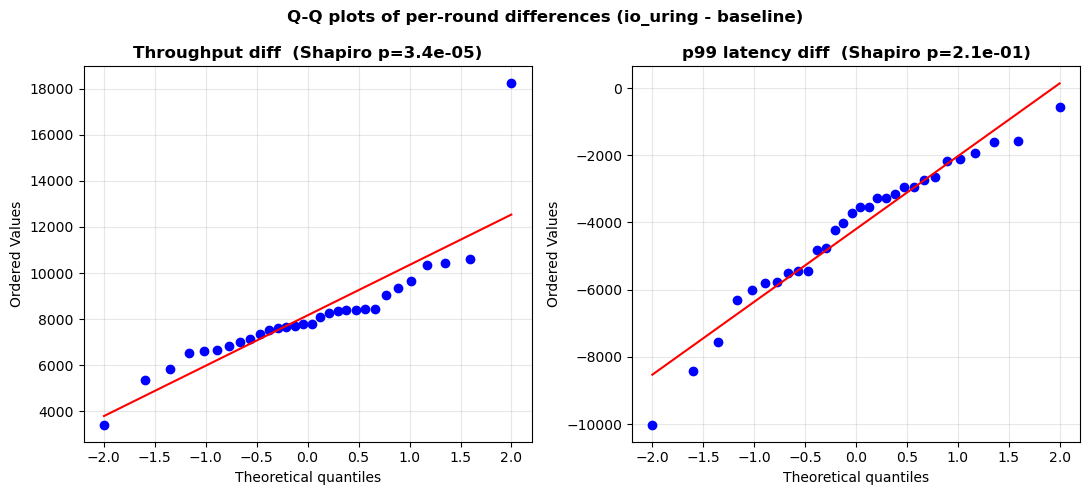

Q-Q plot saved to: benchmark_qq.png


In [4]:
from scipy.stats import probplot

suffix = 'consumer_' if CONSUMER_MODE else ''

ncols_qq = 2 if has_p99 else 1
fig, axes = plt.subplots(1, ncols_qq, figsize=(5.5 * ncols_qq, 5))
if ncols_qq == 1:
    axes = [axes]

probplot(diff_tp, dist='norm', plot=axes[0])
axes[0].set_title(f'{tp_label} diff  (Shapiro p={p_sw_tp:.1e})', fontweight='bold')
axes[0].grid(alpha=0.3)

if has_p99:
    probplot(diff_p99, dist='norm', plot=axes[1])
    axes[1].set_title(f'p99 latency diff  (Shapiro p={p_sw_p99:.1e})', fontweight='bold')
    axes[1].grid(alpha=0.3)

fig.suptitle('Q-Q plots of per-round differences (io_uring - baseline)', fontweight='bold')
plt.tight_layout()
qq_path = OUT_DIR / f'{suffix}benchmark_qq.png'
plt.savefig(qq_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Q-Q plot saved to: {qq_path}')

## 3. Boxplots with jitter and significance markers

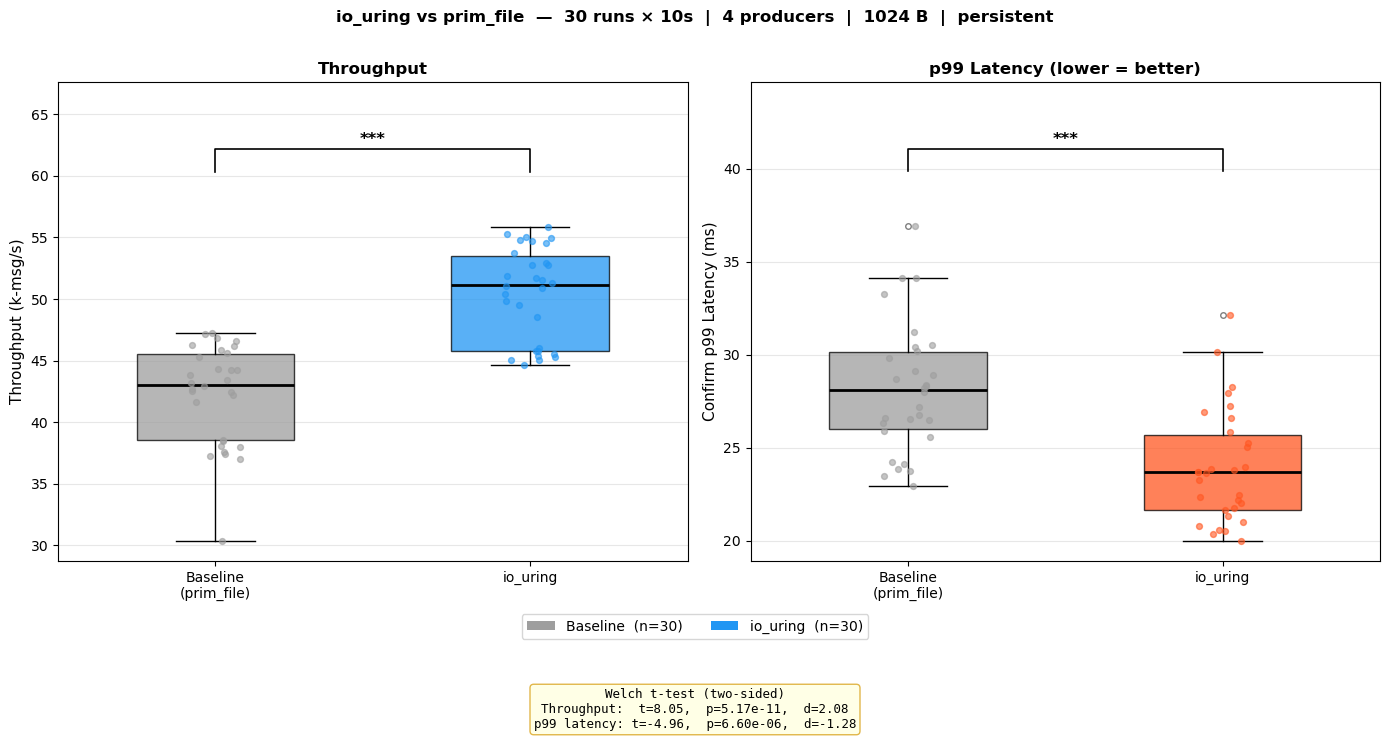

Plot saved to: benchmark_boxplots.png


In [5]:
BLUE   = '#2196F3'
ORANGE = '#FF5722'
GRAY   = '#9E9E9E'

has_p99 = b_p99 is not None and len(b_p99) > 0
ncols   = 2 if has_p99 else 1
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))
if ncols == 1:
    axes = [axes]

fig.suptitle(
    f'io_uring vs prim_file  —  {RUNS} runs × {DURATION}s'
    f'  |  {hdr_label}  |  {MSG_SIZE} B  |  persistent',
    fontsize=12, fontweight='bold', y=1.01,
)

def style_box(bplot, colors):
    for patch, c in zip(bplot['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    for med in bplot['medians']:
        med.set_color('black')
        med.set_linewidth(2)

def sig_bracket(ax, p, y, x0, x1):
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    h = y * 0.03
    ax.plot([x0, x0, x1, x1], [y, y + h, y + h, y], lw=1.2, c='black')
    ax.text((x0 + x1) / 2, y + h * 1.1, stars, ha='center', va='bottom',
            fontsize=12, fontweight='bold')

jitter = np.random.default_rng(0).uniform(-0.08, 0.08, max(len(b_tp), len(i_tp)))

# Throughput
ax = axes[0]
bplot = ax.boxplot(
    [b_tp / 1_000, i_tp / 1_000],
    tick_labels=['Baseline\n(prim_file)', 'io_uring'],
    patch_artist=True, widths=0.5, showfliers=True,
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
)
style_box(bplot, [GRAY, BLUE])
ax.set_ylabel('Throughput (k-msg/s)', fontsize=11)
ax.set_title(tp_label, fontsize=12, fontweight='bold')
ax.scatter(1 + jitter[:len(b_tp)], b_tp / 1_000, s=18, c=GRAY, alpha=0.6, zorder=5)
ax.scatter(2 + jitter[:len(i_tp)], i_tp / 1_000, s=18, c=BLUE, alpha=0.6, zorder=5)
y_top = max(b_tp.max(), i_tp.max()) / 1_000 * 1.08
sig_bracket(ax, stats_res['p_tp'], y_top, 1, 2)
ax.set_ylim(top=y_top * 1.12)
ax.grid(axis='y', alpha=0.3)

# P99 latency (optional)
if has_p99:
    ax = axes[1]
    bplot = ax.boxplot(
        [b_p99 / 1_000, i_p99 / 1_000],
        tick_labels=['Baseline\n(prim_file)', 'io_uring'],
        patch_artist=True, widths=0.5, showfliers=True,
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
    )
    style_box(bplot, [GRAY, ORANGE])
    ax.set_ylabel('Confirm p99 Latency (ms)', fontsize=11)
    ax.set_title('p99 Latency (lower = better)', fontsize=12, fontweight='bold')
    ax.scatter(1 + jitter[:len(b_p99)], b_p99 / 1_000, s=18, c=GRAY,   alpha=0.6, zorder=5)
    ax.scatter(2 + jitter[:len(i_p99)], i_p99 / 1_000, s=18, c=ORANGE, alpha=0.6, zorder=5)
    y_top = max(b_p99.max(), i_p99.max()) / 1_000 * 1.08
    sig_bracket(ax, stats_res['p_p99'], y_top, 1, 2)
    ax.set_ylim(top=y_top * 1.12)
    ax.grid(axis='y', alpha=0.3)

legend_handles = [
    mpatches.Patch(fc=GRAY, label=f'Baseline  (n={len(b_tp)})'),
    mpatches.Patch(fc=BLUE, label=f'io_uring  (n={len(i_tp)})'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.05), fontsize=10)

annot = [f'Welch t-test (two-sided)',
         f'Throughput:  t={stats_res["t_tp"]:.2f},  p={stats_res["p_tp"]:.2e},  d={stats_res["d_tp"]:.2f}']
if has_p99 and stats_res['t_p99'] is not None:
    annot.append(f'p99 latency: t={stats_res["t_p99"]:.2f},  p={stats_res["p_p99"]:.2e},  d={stats_res["d_p99"]:.2f}')
fig.text(0.5, -0.12, '\n'.join(annot), ha='center', va='top',
         fontsize=9, family='monospace',
         bbox=dict(boxstyle='round', fc='lightyellow', ec='goldenrod', alpha=0.8))

plt.tight_layout()
suffix = 'consumer_' if CONSUMER_MODE else ''
boxplot_path = OUT_DIR / f'{suffix}benchmark_boxplots.png'
plt.savefig(boxplot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to: {boxplot_path}')

## 4. Time series — run stability

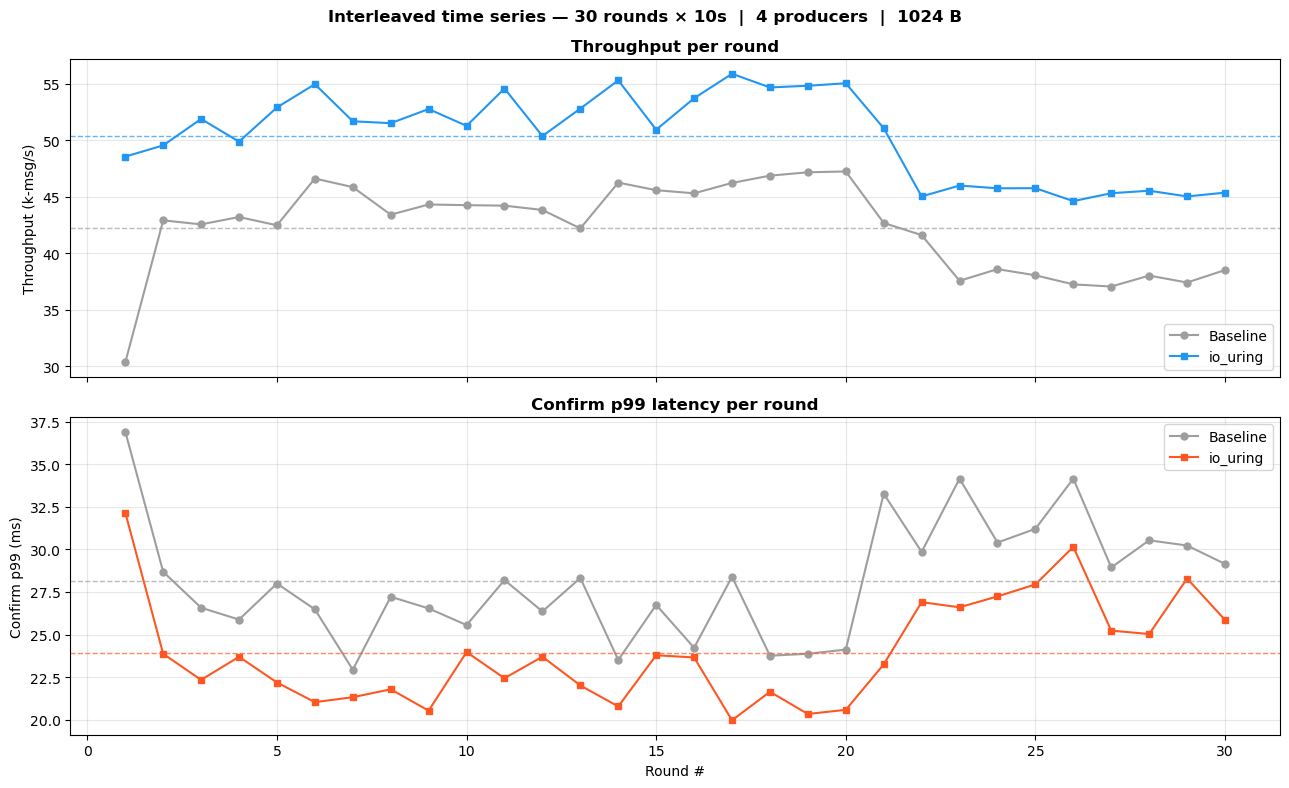

Time series saved to: benchmark_timeseries.png


In [6]:
nrows = 2 if has_p99 else 1
fig, axes = plt.subplots(nrows, 1, figsize=(13, 4 * nrows), sharex=True)
if nrows == 1:
    axes = [axes]
runs_x = np.arange(1, len(b_tp) + 1)

ax = axes[0]
ax.plot(runs_x, b_tp / 1_000, 'o-', c=GRAY, label='Baseline', lw=1.5, ms=5)
ax.plot(runs_x, i_tp / 1_000, 's-', c=BLUE, label='io_uring', lw=1.5, ms=5)
ax.axhline(b_tp.mean() / 1_000, c=GRAY, ls='--', lw=1, alpha=0.7)
ax.axhline(i_tp.mean() / 1_000, c=BLUE, ls='--', lw=1, alpha=0.7)
ax.set_ylabel('Throughput (k-msg/s)')
ax.set_title(f'{tp_label} per round', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

if has_p99:
    ax = axes[1]
    ax.plot(runs_x, b_p99 / 1_000, 'o-', c=GRAY,   label='Baseline', lw=1.5, ms=5)
    ax.plot(runs_x, i_p99 / 1_000, 's-', c=ORANGE, label='io_uring', lw=1.5, ms=5)
    ax.axhline(b_p99.mean() / 1_000, c=GRAY,   ls='--', lw=1, alpha=0.7)
    ax.axhline(i_p99.mean() / 1_000, c=ORANGE, ls='--', lw=1, alpha=0.7)
    ax.set_ylabel('Confirm p99 (ms)')
    ax.set_title('Confirm p99 latency per round', fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Round #')
fig.suptitle(
    f'Interleaved time series — {RUNS} rounds × {DURATION}s  |  {hdr_label}  |  {MSG_SIZE} B',
    fontweight='bold',
)
plt.tight_layout()
timeseries_path = OUT_DIR / f'{suffix}benchmark_timeseries.png'
plt.savefig(timeseries_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Time series saved to: {timeseries_path}')

## 4c. Difference per round (interleaved design)

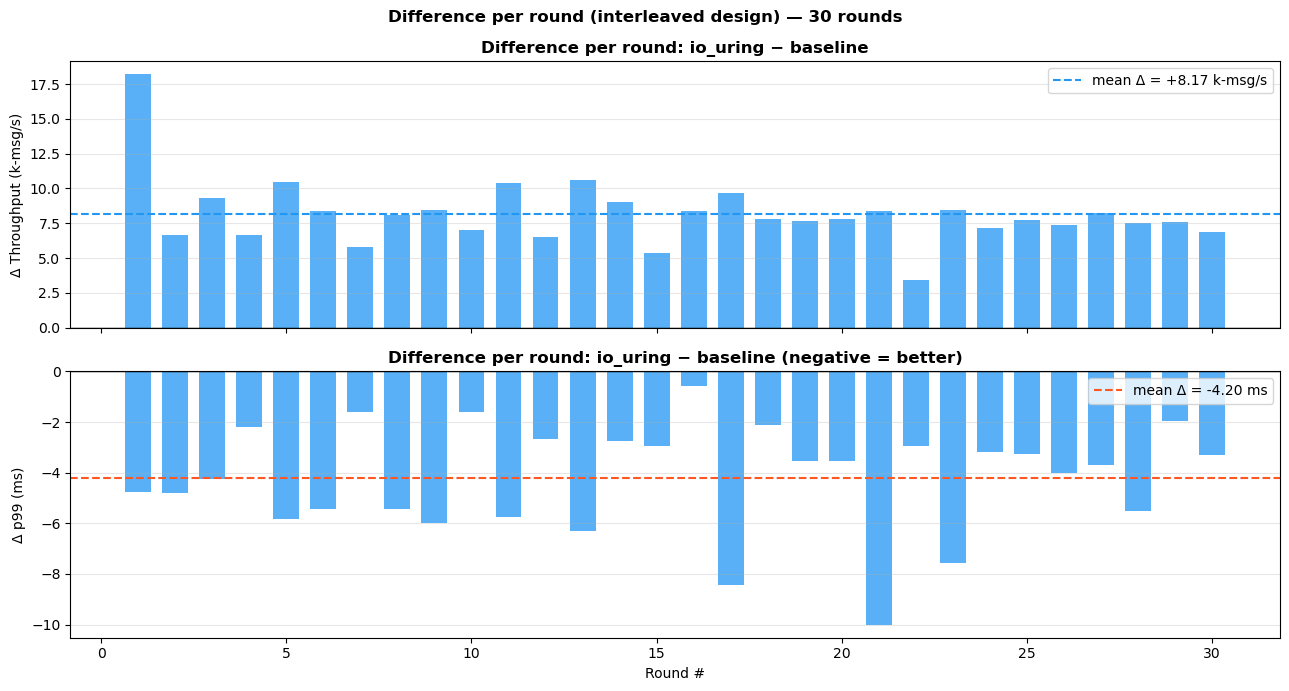

Per-round difference saved to: benchmark_diff.png


In [7]:
# Shows io_uring[i] − baseline[i] for each round — visual evidence of the paired effect
nrows = 2 if has_p99 else 1
fig, axes = plt.subplots(nrows, 1, figsize=(13, 3.5 * nrows), sharex=True)
if nrows == 1:
    axes = [axes]
pairs_x = np.arange(1, len(b_tp) + 1)

ax = axes[0]
colors_tp = [BLUE if d > 0 else ORANGE for d in diff_tp]
ax.bar(pairs_x, diff_tp / 1_000, color=colors_tp, alpha=0.75, width=0.7)
ax.axhline(0, c='black', lw=1)
ax.axhline(diff_tp.mean() / 1_000, c=BLUE, ls='--', lw=1.5,
           label=f'mean Δ = {diff_tp.mean()/1_000:+.2f} k-msg/s')
ax.set_ylabel('Δ Throughput (k-msg/s)')
ax.set_title('Difference per round: io_uring − baseline', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

if has_p99:
    ax = axes[1]
    colors_p99 = [ORANGE if d > 0 else BLUE for d in diff_p99]
    ax.bar(pairs_x, diff_p99 / 1_000, color=colors_p99, alpha=0.75, width=0.7)
    ax.axhline(0, c='black', lw=1)
    ax.axhline(diff_p99.mean() / 1_000, c=ORANGE, ls='--', lw=1.5,
               label=f'mean Δ = {diff_p99.mean()/1_000:+.2f} ms')
    ax.set_ylabel('Δ p99 (ms)')
    ax.set_title('Difference per round: io_uring − baseline (negative = better)', fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('Round #')
fig.suptitle(
    f'Difference per round (interleaved design) — {RUNS} rounds',
    fontweight='bold',
)
plt.tight_layout()
diff_path = OUT_DIR / f'{suffix}benchmark_diff.png'
plt.savefig(diff_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Per-round difference saved to: {diff_path}')

## 4b. Separate PDFs for LaTeX (no legend, English axis labels)

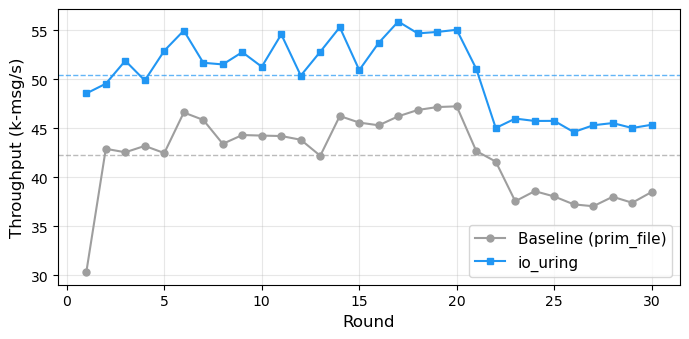

Throughput PDF: timeseries_throughput.pdf


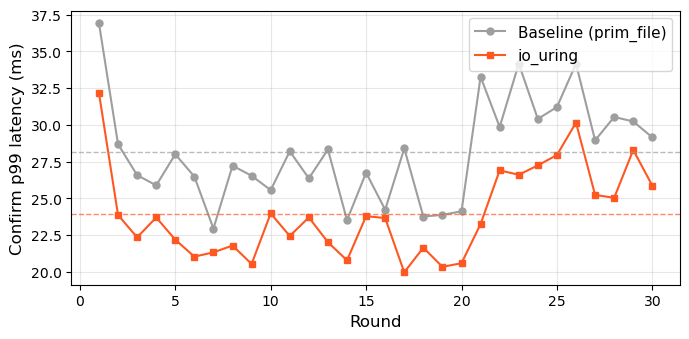

Latency PDF: timeseries_latency.pdf


In [8]:
suffix = 'consumer_' if CONSUMER_MODE else ''

# ── Throughput PDF ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
runs_x = np.arange(1, len(b_tp) + 1)

ax.plot(runs_x, b_tp / 1_000, 'o-', c=GRAY, lw=1.5, ms=5, label='Baseline (prim_file)')
ax.plot(runs_x, i_tp / 1_000, 's-', c=BLUE, lw=1.5, ms=5, label='io_uring')
ax.axhline(b_tp.mean() / 1_000, c=GRAY, ls='--', lw=1, alpha=0.7)
ax.axhline(i_tp.mean() / 1_000, c=BLUE, ls='--', lw=1, alpha=0.7)
ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Throughput (k-msg/s)', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
tp_pdf = OUT_DIR / f'{suffix}timeseries_throughput.pdf'
plt.savefig(tp_pdf, format='pdf', bbox_inches='tight')
plt.show()
print(f'Throughput PDF: {tp_pdf}')

# ── Latency PDF ─────────────────────────────────────────────────────────────
if has_p99:
    fig, ax = plt.subplots(figsize=(7, 3.5))

    ax.plot(runs_x, b_p99 / 1_000, 'o-', c=GRAY,   lw=1.5, ms=5, label='Baseline (prim_file)')
    ax.plot(runs_x, i_p99 / 1_000, 's-', c=ORANGE, lw=1.5, ms=5, label='io_uring')
    ax.axhline(b_p99.mean() / 1_000, c=GRAY,   ls='--', lw=1, alpha=0.7)
    ax.axhline(i_p99.mean() / 1_000, c=ORANGE, ls='--', lw=1, alpha=0.7)
    ax.set_xlabel('Round', fontsize=12)
    ax.set_ylabel('Confirm p99 latency (ms)', fontsize=12)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    lat_pdf = OUT_DIR / f'{suffix}timeseries_latency.pdf'
    plt.savefig(lat_pdf, format='pdf', bbox_inches='tight')
    plt.show()
    print(f'Latency PDF: {lat_pdf}')

## 5. Distribution (histogram + KDE)

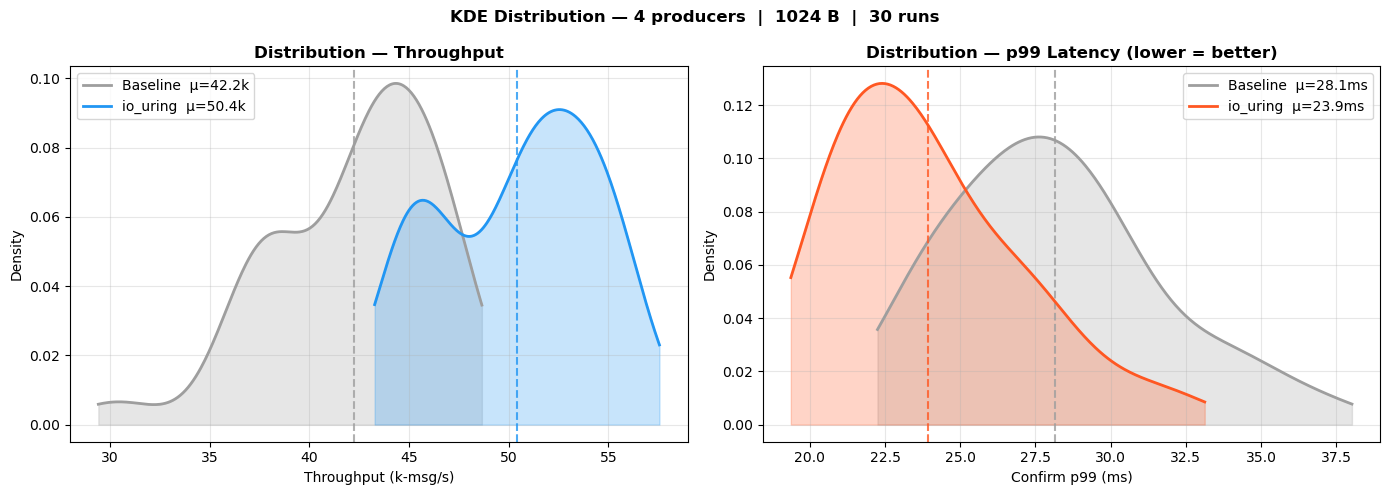

KDE plot saved to: benchmark_kde.png


In [9]:
from scipy.stats import gaussian_kde

ncols = 2 if has_p99 else 1
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
if ncols == 1:
    axes = [axes]

def kde_plot(ax, data, color, label):
    kde = gaussian_kde(data, bw_method='scott')
    x = np.linspace(data.min() * 0.97, data.max() * 1.03, 300)
    ax.fill_between(x, kde(x), alpha=0.25, color=color)
    ax.plot(x, kde(x), color=color, lw=2, label=label)
    ax.axvline(data.mean(), color=color, ls='--', lw=1.5, alpha=0.8)

ax = axes[0]
kde_plot(ax, b_tp / 1_000, GRAY, f'Baseline  μ={b_tp.mean()/1_000:.1f}k')
kde_plot(ax, i_tp / 1_000, BLUE, f'io_uring  μ={i_tp.mean()/1_000:.1f}k')
ax.set_xlabel('Throughput (k-msg/s)')
ax.set_ylabel('Density')
ax.set_title(f'Distribution — {tp_label}', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

if has_p99:
    ax = axes[1]
    kde_plot(ax, b_p99 / 1_000, GRAY,   f'Baseline  μ={b_p99.mean()/1_000:.1f}ms')
    kde_plot(ax, i_p99 / 1_000, ORANGE, f'io_uring  μ={i_p99.mean()/1_000:.1f}ms')
    ax.set_xlabel('Confirm p99 (ms)')
    ax.set_ylabel('Density')
    ax.set_title('Distribution — p99 Latency (lower = better)', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle(
    f'KDE Distribution — {hdr_label}  |  {MSG_SIZE} B  |  {RUNS} runs',
    fontweight='bold',
)
plt.tight_layout()
kde_path = OUT_DIR / f'{suffix}benchmark_kde.png'
plt.savefig(kde_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'KDE plot saved to: {kde_path}')

## 6. Final summary

In [10]:
print('\n' + '═' * 62)
print('  SUMMARY')
print('═' * 62)
print(f'  Throughput  : {delta_tp_p:+.1f}%  ({sig_stars(p_tp_p)})  dz={dz_tp:.2f} ({effect_label(dz_tp)})')
if has_p99 and stats_res['p_p99'] is not None:
    print(f'  P99 latency : {delta_p99_p:+.1f}%  ({sig_stars(p_p99_p)})  dz={dz_p99:.2f} ({effect_label(dz_p99)})')
norm_tp  = normality_label(p_sw_tp)
norm_p99 = normality_label(p_sw_p99) if has_p99 else 'n/a'
print(f'  Normality (diff): throughput {norm_tp}, p99 {norm_p99}')
bonf_tp = bonferroni_verdict(p_tp_p, ALPHA_BONF)
print(f'  Bonferroni (alpha={ALPHA_BONF}): throughput paired p {bonf_tp}', end='')
if has_p99 and stats_res['p_p99'] is not None:
    bonf_p99 = bonferroni_verdict(p_p99_p, ALPHA_BONF)
    print(f', p99 paired p {bonf_p99}')
else:
    print()
print('═' * 62)
print(f'  Files written to: {OUT_DIR}/')


══════════════════════════════════════════════════════════════
  SUMMARY
══════════════════════════════════════════════════════════════
  Throughput  : +19.3%  (*** (p < 0.001))  dz=3.36 (large)
  P99 latency : -14.9%  (*** (p < 0.001))  dz=-1.96 (large)
  Normality (diff): throughput not normal -> trust Wilcoxon instead, p99 normal
  Bonferroni (alpha=0.025): throughput paired p significant, p99 paired p significant
══════════════════════════════════════════════════════════════
  Files written to: ./
